# CNMF-E pipeline — part 1: load & motion-correct

This is the first of three demo notebooks for **minicnmfe**. It loads a raw
1-photon miniscope recording, converts it to a lazy `zarr` store, and runs
**rigid motion correction**.

It runs on a small **simulated** movie so it is fully reproducible. Generate
the demo movies once from the repo root:

```bash
python generate_demo_movies.py
```

We use `realistic_medium` — a 128×128, 600-frame movie with 15 neurons, a
drifting 1p background, vasculature, vignetting, photobleaching, shot noise,
8-bit quantisation, and a built-in **8-px motion drift** that motion correction
should remove. Because it is simulated we also know the ground-truth drift, so
at the end we check the recovered shifts against it.

**Outline:** ingest AVI → zarr · inspect · configure MC · run streaming MC ·
verify quality · save shifts. Part 2 (`02_extract_components.ipynb`) extracts
neurons from the corrected movie.

## 1. Imports

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np

from minicnmfe.io import avi_to_zarr, open_zarr
from minicnmfe.pipeline import CNMFe, CNMFeParams

## 2. Paths

The notebook finds the repo root automatically (it works whether you launched
Jupyter from the repo root or from `demo_notebooks/`).

In [2]:
def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "minicnmfe").exists():
            return cand
    raise FileNotFoundError("Could not locate the minicnmfe repo root.")

REPO = find_repo_root()
DEMO = REPO / "demo_movies"
rel = lambda p: Path(p).relative_to(REPO)            # repo-relative display

AVI_PATH    = DEMO / "realistic_medium.avi"          # input (simulated)
SESSION_ZARR = DEMO / "realistic_medium.zarr"        # AVI -> zarr lands here
OUTPUT_DIR  = DEMO / "realistic_medium_out"          # mc.zarr + shifts.npy
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert AVI_PATH.exists(), (
    "realistic_medium.avi not found — run `python generate_demo_movies.py`"
)
print(f"repo root : {REPO.name}/")
print(f"input AVI : {rel(AVI_PATH)}")
print(f"output dir: {rel(OUTPUT_DIR)}")

repo root : simpler_cnmfe/
input AVI : demo_movies/realistic_medium.avi
output dir: demo_movies/realistic_medium_out


## 3. Ingest — AVI → zarr

`avi_to_zarr` decodes the video frame-by-frame into a time-chunked `zarr`
store; it never holds the whole movie in RAM. The store is opened lazily later,
so only the frames you touch are decoded.

> **Real miniscope sessions** are usually a *folder* of numbered AVIs
> (`0.avi`, `1.avi`, …). For that, use
> `from minicnmfe import concat_avis_to_zarr` and point it at the folder — it
> concatenates them into one zarr in a single pass. Here we have a single file,
> so `avi_to_zarr` is enough.

In [3]:
t0 = time.time()
z = avi_to_zarr(AVI_PATH, SESSION_ZARR, chunk_t=100, grayscale=True, dtype="uint8")
print(f"wrote {rel(SESSION_ZARR)}  in {time.time() - t0:.1f}s")
print(f"  shape={z.shape}  chunks={z.chunks}  dtype={z.dtype}")

wrote demo_movies/realistic_medium.zarr  in 0.3s
  shape=(600, 128, 128)  chunks=(100, 128, 128)  dtype=uint8


## 4. Inspect the zarr

In [4]:
z = open_zarr(SESSION_ZARR)
T, H, W = z.shape
print(f"shape  : {z.shape}")
print(f"chunks : {z.chunks}")
print(f"dtype  : {z.dtype}")
print(f"on-disk size : ~{z.nbytes / 1e6:.0f} MB (uncompressed equivalent)")

shape  : (600, 128, 128)
chunks : (100, 128, 128)
dtype  : uint8
on-disk size : ~10 MB (uncompressed equivalent)


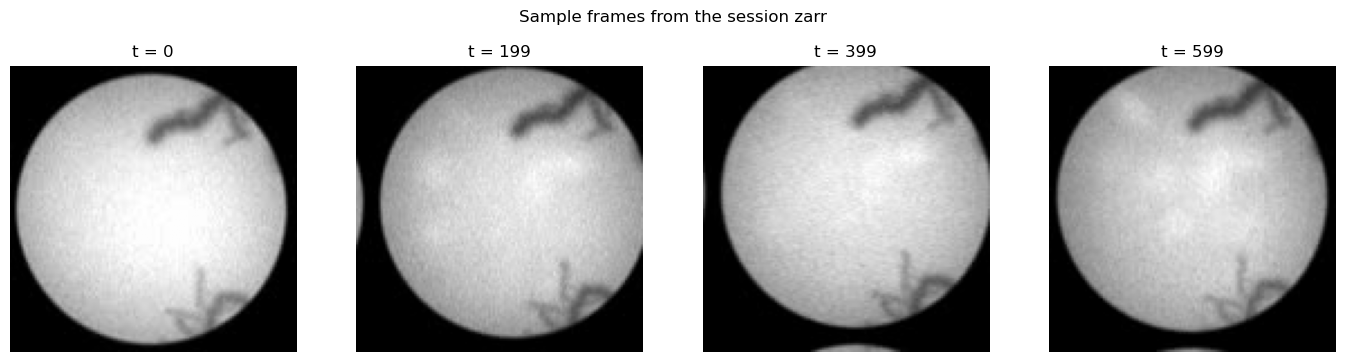

In [5]:
# Four evenly-spaced sample frames (only these slices are decoded).
sample_idx = np.linspace(0, T - 1, 4).astype(int)
sample = np.stack([np.asarray(z[t]) for t in sample_idx], axis=0)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, t, img in zip(axes, sample_idx, sample):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"t = {t}")
    ax.axis("off")
fig.suptitle("Sample frames from the session zarr", y=1.02)
plt.tight_layout()
plt.show()

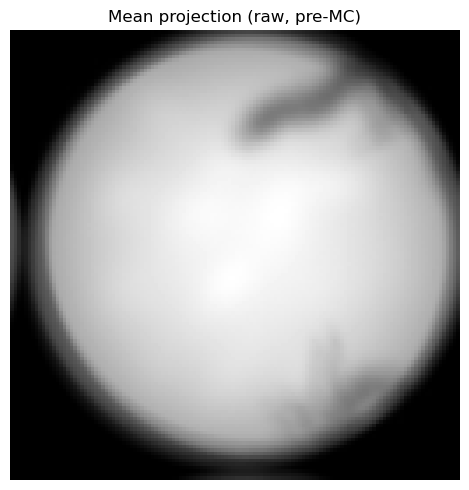

In [6]:
# Mean projection — streamed in batches so RAM stays bounded.
def mean_projection(zarr_arr, batch_size=200):
    T = zarr_arr.shape[0]
    acc = np.zeros(zarr_arr.shape[1:], dtype=np.float64)
    for start in range(0, T, batch_size):
        end = min(start + batch_size, T)
        acc += np.asarray(zarr_arr[start:end], dtype=np.float64).sum(axis=0)
    return (acc / T).astype(np.float32)

raw_mean = mean_projection(z)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(raw_mean, cmap="gray")
ax.set_title("Mean projection (raw, pre-MC)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Configure motion correction

Motion-correction knobs live on `CNMFeParams` (the same object that configures
extraction in part 2):

| Field | Meaning |
|-------|---------|
| `max_shift` | largest correction allowed, `(dy, dx)` px |
| `mc_gSig_filt` | 1p spatial high-pass σ (set `None` for 2p) — sharpens cells for registration |
| `upsample_factor` | sub-pixel registration precision |
| `mc_n_iter` | template-refinement passes (1 = CaImAn default) |
| `mc_batch_size`, `mc_template_max_frames` | streaming batch size / template sample cap |
| `n_jobs` | CPU workers (`-1` = all cores) |

Peak RAM for the MC step is bounded by
`(mc_batch_size + mc_template_max_frames) · H · W · 4` bytes — independent of
the total frame count.

In [7]:
params = CNMFeParams(
    max_shift=(15, 15),          # built-in drift peaks at ~8 px; leave headroom
    upsample_factor=20,          # sub-pixel registration precision
    mc_n_iter=2,                 # 2 template-refinement passes
    mc_gSig_filt=5,              # 1p high-pass sigma (~neuron radius); None for 2p
    mc_batch_size=200,
    mc_template_max_frames=2000,
    mc_output_chunk_t=None,      # None = match source chunks
    mc_output_dtype="float32",
    n_jobs=-1,
)

peak_mb = (params.mc_batch_size + params.mc_template_max_frames) * H * W * 4 / 1e6
print(f"estimated peak RAM (MC step): ~{peak_mb:.0f} MB")

estimated peak RAM (MC step): ~144 MB


## 6. Run streaming motion correction

`fit_mc` reads the source zarr in batches and writes the corrected movie to
`<output_dir>/mc.zarr` without ever materialising all frames in RAM. The
per-frame correction shifts land on `model.shifts` as a `(T, 2)` float32 array.

In [8]:
model = CNMFe(params)

t0 = time.time()
mc = model.fit_mc(z, output_dir=OUTPUT_DIR)
mc_elapsed = time.time() - t0

print(f"\nMC finished in {mc_elapsed:.1f}s")
print(f"  corrected zarr : {rel(OUTPUT_DIR / 'mc.zarr')}")
print(f"  mc.shape       : {mc.shape}")
print(f"  mc.chunks      : {mc.chunks}")
print(f"  mc.dtype       : {mc.dtype}")
print(f"  model.shifts   : {model.shifts.shape}  {model.shifts.dtype}")

Building template from strided sample...


MC template:   0%|          | 0/3 [00:00<?, ?it/s]

MC template:  67%|██████▋   | 2/3 [00:00<00:00, 18.42it/s]

MC template: 100%|██████████| 3/3 [00:00<00:00, 18.42it/s]

  template built from 600 sampled frames in 0.2s
Rigid iteration 1/2


...

  template built from 600 sampled frames in 0.2s
Rigid iteration 2/2


MC pass 2/2:   0%|          | 0/3 [00:00<?, ?it/s]

MC pass 2/2:  67%|██████▋   | 2/3 [00:00<00:00,  8.59it/s]

MC pass 2/2: 100%|██████████| 3/3 [00:00<00:00,  9.32it/s]

  MC pass 2/2: 600 frames (read+MC+write) in 0.3s (1856 fps)
  final mc.zarr move scratch -> output in 0.0s

MC finished in 3.3s
  corrected zarr : demo_movies/realistic_medium_out/mc.zarr
  mc.shape       : (600, 128, 128)
  mc.chunks      : (100, 128, 128)
  mc.dtype       : float32
  model.shifts   : (600, 2)  float32


## 7. Verify MC quality

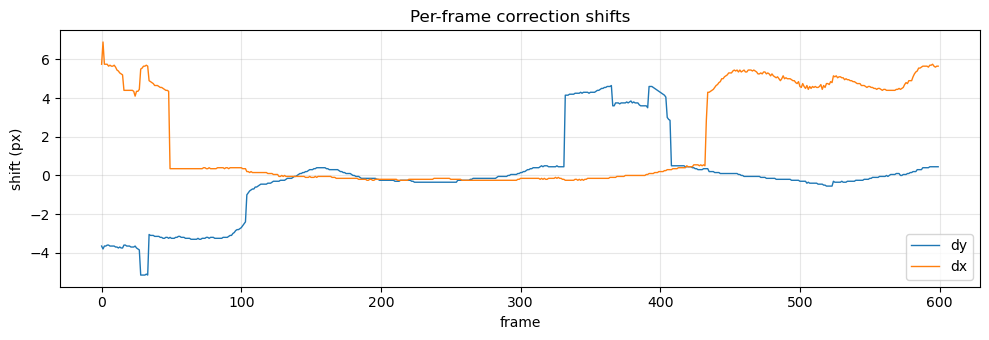

  dy : min=-5.15  max=+4.65   std=2.06
  dx : min=-0.25  max=+6.90   std=2.41


In [9]:
shifts = model.shifts   # (T, 2) — (dy, dx) per frame

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(shifts[:, 0], label="dy", lw=1)
ax.plot(shifts[:, 1], label="dx", lw=1)
ax.set_xlabel("frame")
ax.set_ylabel("shift (px)")
ax.set_title("Per-frame correction shifts")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  dy : min={shifts[:, 0].min():+.2f}  max={shifts[:, 0].max():+.2f}   std={shifts[:, 0].std():.2f}")
print(f"  dx : min={shifts[:, 1].min():+.2f}  max={shifts[:, 1].max():+.2f}   std={shifts[:, 1].std():.2f}")

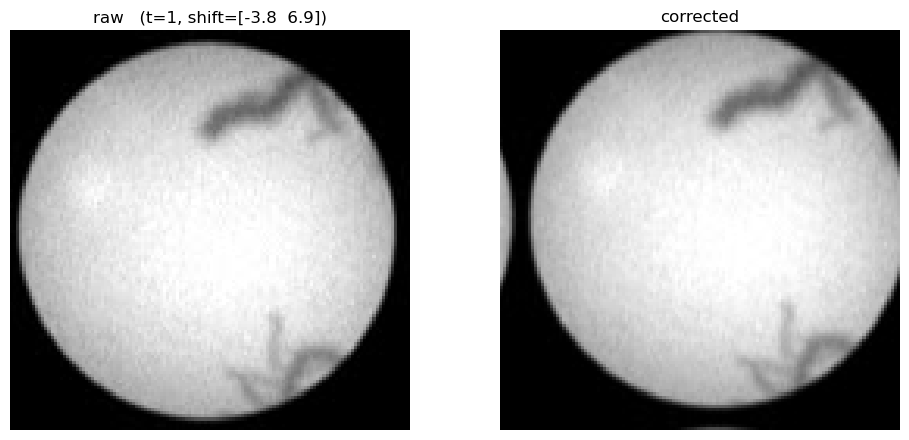

In [10]:
# Compare the worst-motion frame before/after correction.
peak_t = int(np.argmax(np.linalg.norm(shifts, axis=1)))
raw_peak = np.asarray(z[peak_t], dtype=np.float32)
mc_peak  = np.asarray(mc[peak_t], dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(raw_peak, cmap="gray")
axes[0].set_title(f"raw   (t={peak_t}, shift={np.round(shifts[peak_t], 1)})")
axes[0].axis("off")
axes[1].imshow(mc_peak, cmap="gray")
axes[1].set_title("corrected")
axes[1].axis("off")
plt.tight_layout()
plt.show()

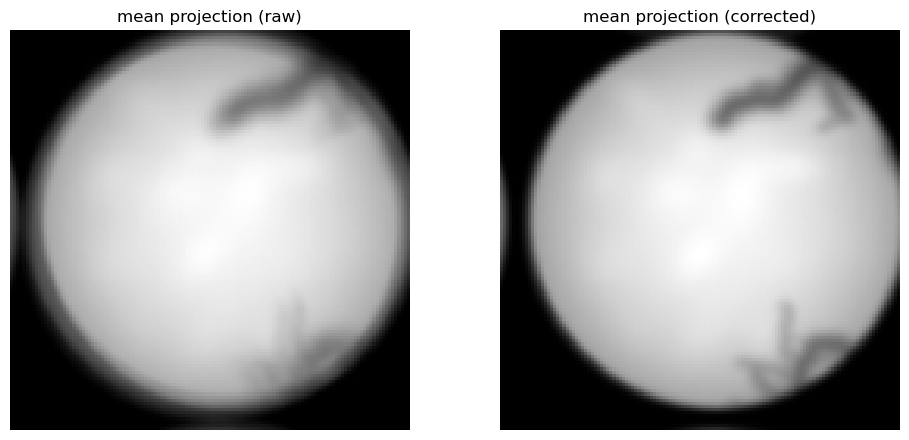

In [11]:
# A sharper mean projection after MC = less motion blur.
mc_mean = mean_projection(mc)
vmin = min(raw_mean.min(), mc_mean.min())
vmax = max(raw_mean.max(), mc_mean.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(raw_mean, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("mean projection (raw)")
axes[0].axis("off")
axes[1].imshow(mc_mean, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("mean projection (corrected)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 8. Sanity check against the ground-truth drift

Because the movie is simulated, the sidecar `realistic_medium_meta.npz` stores
the exact drift applied to each frame (`motion_shifts`). The correction MC
estimates should be approximately its **negative** (it undoes the drift), so
`model.shifts ≈ -motion_shifts`.

Rigid MC corrects *relative* motion, so a constant offset between the recovered
shifts and the true drift is expected and harmless (the whole movie is shifted
by the same amount; the neurons still line up). The meaningful score is
therefore the **per-axis correlation** (does the recovered trajectory track the
true one?) plus the **mean-centered residual**. On real data you don't have the
ground truth — judge MC by the sharper mean projection above instead.

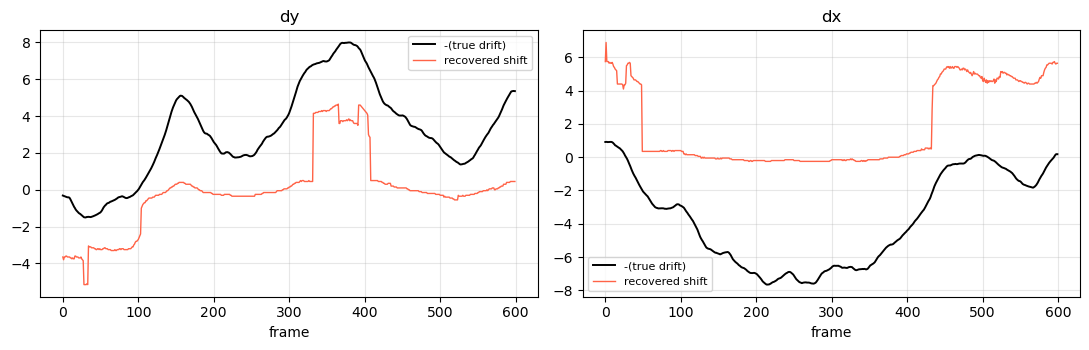

  dy: corr(recovered, -true) = +0.917   mean-centered residual RMS = 1.05 px
  dx: corr(recovered, -true) = +0.900   mean-centered residual RMS = 1.22 px


In [12]:
meta = np.load(DEMO / "realistic_medium_meta.npz")
true_drift = meta["motion_shifts"]          # (T, 2) drift applied per frame
recovered  = model.shifts                   # (T, 2) correction MC estimated

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for j, name in enumerate(["dy", "dx"]):
    axes[j].plot(-true_drift[:, j], lw=1.4, color="black", label="-(true drift)")
    axes[j].plot(recovered[:, j], lw=1.0, color="tomato", label="recovered shift")
    axes[j].set_title(name)
    axes[j].set_xlabel("frame")
    axes[j].legend(fontsize=8)
    axes[j].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Per-axis correlation (shape match) + mean-centered residual RMS
# (a constant offset between the two is expected, so we remove it first).
for j, name in enumerate(["dy", "dx"]):
    rec, tgt = recovered[:, j], -true_drift[:, j]
    r = np.corrcoef(rec, tgt)[0, 1]
    resid = (rec - rec.mean()) - (tgt - tgt.mean())
    print(f"  {name}: corr(recovered, -true) = {r:+.3f}   "
          f"mean-centered residual RMS = {float(np.sqrt(np.mean(resid ** 2))):.2f} px")

## 9. Save shifts to disk

In [13]:
shifts_path = OUTPUT_DIR / "shifts.npy"
np.save(shifts_path, model.shifts)
print(f"saved -> {rel(shifts_path)}   shape={model.shifts.shape}  dtype={model.shifts.dtype}")

saved -> demo_movies/realistic_medium_out/shifts.npy   shape=(600, 2)  dtype=float32


## 10. What's next

The corrected movie is on disk at `realistic_medium_out/mc.zarr`. Continue with
**`02_extract_components.ipynb`**, which loads it and runs the full extraction
(CORR/PNR seeding → ring background → spatial/temporal refinement → merging →
auto-evaluation).

- Re-open the corrected movie anywhere with `open_zarr(OUTPUT_DIR / "mc.zarr")`.
- For very long recordings (60k+ frames) the corrected zarr can be transposed
  to a pixel-major store with `transpose_zarr_to_pixel_major` so extraction
  streams with RAM independent of frame count — see part 2, final section.